In [ ]:
import pandas as pd

df = pd.read_csv("Heart_disease_cleveland_new.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


## Class Imbalance Problem

In this dataset, the number of patients with heart disease is not equal to the number of patients without heart disease. This creates a class imbalance.

Machine learning models trained on imbalanced data tend to favor the majority class, which can lead to poor prediction performance for the minority class.

To address this issue, data balancing techniques such as SMOTE (Synthetic Minority Oversampling Technique) are used. This helps in improving model performance and fairness.

In [ ]:
df['target'].value_counts()

,count
target,
0,164
1,139


In [ ]:
from imblearn.over_sampling import SMOTE

X = df.drop('target', axis=1)
y = df['target']

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

<Axes: xlabel='target', ylabel='count'>

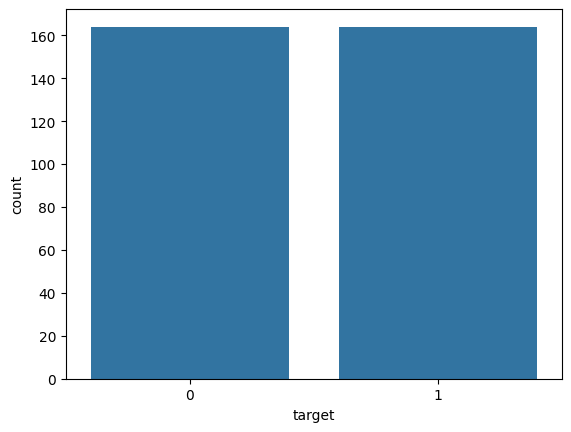

In [ ]:
import seaborn as sns
sns.countplot(x=y_res)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        29
           1       0.86      0.81      0.83        37

    accuracy                           0.82        66
   macro avg       0.82      0.82      0.82        66
weighted avg       0.82      0.82      0.82        66



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
